# 02 · Finding Minima and Maxima

Chapter 01 fit a line by calling `.fit()` and trusting scikit-learn to find the best
coefficients. This chapter opens that box: the calculus that finds a function's
minima and maxima is *exactly* what every training loop in this course is doing,
whether it's ordinary least squares, gradient descent, or backpropagation.

**Objectives:** find critical points with derivatives, classify them with the
second-derivative test, and connect this to how a model is "trained" at all.

## 1. Slopes, critical points and curvature

Picture walking along the graph of a function $f(x)$. The **derivative** measures how steep the ground is at each point: the rise over the run of a tiny step $h$, in the limit where the step shrinks to nothing:

$$f'(x) = \lim_{h \to 0} \frac{f(x+h) - f(x)}{h}$$

The fraction is the slope of the chord between $x$ and $x+h$; as $h$ shrinks, the chord becomes the tangent. For $f(x) = x^2$ at $x = 3$ the fraction is $\big((3+h)^2 - 9\big)/h = (6h + h^2)/h = 6 + h$. For $h = 1, 0.1, 0.01$ it equals $7, 6.1, 6.01$, closing in on $f'(3) = 6$, which matches the rule $f'(x) = 2x$.

At the top of a hill or the bottom of a valley the ground is flat. So every smooth local maximum or minimum $x^*$ satisfies

$$f'(x^*) = 0$$

Points where the derivative vanishes are called **critical points**. They are only candidates: $f(x) = x^3$ is flat at $0$ yet keeps rising on both sides. To sort the candidates, zoom in with a **Taylor expansion**. Near any point $x$, a smooth function is well described by its value, its slope and its curvature:

$$f(x + h) \approx f(x) + f'(x)\,h + \tfrac12 f''(x)\,h^2$$

Here $f''(x)$, the second derivative, is the slope of the slope: it measures how the graph bends. The three terms are a height, a straight tilt, and a parabola bending up or down. At a critical point the tilt is zero, so

$$f(x^* + h) - f(x^*) \approx \tfrac12 f''(x^*)\,h^2$$

Since $h^2 > 0$ for every small step, left or right, the sign of $f''(x^*)$ decides everything. This is the **second-derivative test**:

- $f''(x^*) > 0$: every nearby point is higher, so $x^*$ is a **local minimum**.
- $f''(x^*) < 0$: every nearby point is lower, so $x^*$ is a **local maximum**.
- $f''(x^*) = 0$: the parabola term vanishes and the test is silent. Higher-order terms decide: $x^3$ has an inflection point at $0$, $x^4$ a minimum.

## 2. Several variables: gradient and Hessian

A model usually has many parameters, collected in a vector $w = (w_1, \dots, w_p)$; $L(w)$ returns one number. The **partial derivative** $\partial L/\partial w_j$ is the ordinary derivative along coordinate $j$, all other coordinates held fixed. Stacking the $p$ of them gives the **gradient**, a $p \times 1$ vector:

$$\nabla L(w) = \Big(\frac{\partial L}{\partial w_1}, \dots, \frac{\partial L}{\partial w_p}\Big)^{\!\top}$$

The gradient points in the direction of steepest ascent, and its length is the slope in that direction. The second derivatives form the symmetric $p \times p$ **Hessian** matrix $H$, with entries $H_{jk} = \partial^2 L / \partial w_j \partial w_k$: it records how the surface bends in every direction. For a small step vector $h$ ($p \times 1$), the Taylor expansion keeps its shape:

$$L(w + h) \approx L(w) + \nabla L(w)^\top h + \tfrac12\, h^\top H\, h$$

A critical point now means $\nabla L(w^*) = 0$: all $p$ slopes vanish together. There, $L(w^* + h) - L(w^*) \approx \tfrac12 h^\top H h$. If $h^\top H h > 0$ for every nonzero $h$ ($H$ is **positive definite**), every direction leads uphill and $w^*$ is a local minimum. If it is negative for every $h$, a local maximum. If the sign depends on the direction, $w^*$ is a **saddle point**.

Two examples. $L = w_1^2 + 3w_2^2$ has gradient $(2w_1, 6w_2)$, zero at the origin, and $h^\top H h = 2h_1^2 + 6h_2^2 > 0$: a minimum, the bottom of a bowl. $L = w_1^2 - w_2^2$ gives $h^\top H h = 2h_1^2 - 2h_2^2$, positive along $w_1$ and negative along $w_2$: a saddle, shaped like a mountain pass.

## 3. Training as minimisation: gradient descent

A model's **loss function** $L(w)$ measures how wrong its predictions are on the training data, as a function of its parameters $w$; the data stay fixed. **Training** means finding the $w$ that makes $L$ smallest. Solving $\nabla L = 0$ on paper is rarely possible, so we walk downhill instead.

**Deriving the step.** Keep only the first-order Taylor term (one parameter first): $L(w + h) \approx L(w) + L'(w)\,h$. Choose the step $h = -\eta\, L'(w)$ with a small number $\eta > 0$. Then

$$L\big(w - \eta L'(w)\big) \approx L(w) - \eta\, L'(w)^2$$

The change $-\eta L'(w)^2$ is negative whenever the slope is not zero, so the step lowers the loss. This gives **gradient descent**:

$$w \leftarrow w - \eta\, L'(w)$$

The positive number $\eta$ is the **learning rate**, or step size. With many parameters the rule is $w \leftarrow w - \eta \nabla L(w)$, and the loss drops by about $\eta \lVert \nabla L \rVert^2$ per step.

**How big a step?** The Taylor argument only holds for small steps. A quadratic shows exactly what happens. Take $L(w) = a\,(w - w^*)^2$ with curvature $a > 0$ and minimum at $w^*$. Its slope is $L'(w) = 2a(w - w^*)$, so one step gives

$$w_{\text{new}} - w^* = (w - w^*) - 2a\eta\,(w - w^*) = (1 - 2a\eta)\,(w - w^*)$$

Each step multiplies the signed distance to the minimum by the same number $1 - 2a\eta$, so $t$ steps multiply it by $(1 - 2a\eta)^t$. Its size, the **contraction factor** $\lvert 1 - 2a\eta \rvert$, tells the whole story:

- $\eta$ tiny: the factor is close to 1 and progress is slow.
- $\eta = 1/(2a)$: the factor is 0 and one step lands exactly on $w^*$.
- $1/(2a) < \eta < 1/a$: $1 - 2a\eta$ lies between $-1$ and $0$, so $w$ overshoots, zig-zags from side to side, and still converges.
- $\eta > 1/a$: $\lvert 1 - 2a\eta \rvert > 1$, every step overshoots further than the last, and the loss explodes.

Near any minimum, Taylor says a smooth loss looks like such a quadratic, with $a = \tfrac12 L''(w^*)$. So the more sharply the loss curves, the smaller the learning rate must be.

**Convexity.** A function is **convex** if the chord between any two points of its graph never passes below the graph; in one variable this means $L''(w) \ge 0$ everywhere. Then every local minimum is a global minimum. Suppose $w$ were a local minimum but some $v$ had $L(v) < L(w)$. On the segment between them convexity gives $L\big(w + \lambda(v - w)\big) \le (1-\lambda)L(w) + \lambda L(v) < L(w)$ for every $0 < \lambda \le 1$, even for tiny $\lambda$, right next to $w$: a contradiction. The squared-error loss of linear regression is convex, so gradient descent cannot get stuck there; the loss of a neural network is not.

**Three steps by hand.** Take $L(w) = (w - 3)^2$, so $a = 1$ and $w^* = 3$, with $\eta = 0.25$ and the start $w_0 = 0$. The slope is $L'(w) = 2(w - 3)$ and the factor is $1 - 2 \times 1 \times 0.25 = 0.5$.

| step $t$ | $w_t$ | $L(w_t)$ | $L'(w_t)$ | $-\eta\,L'(w_t)$ | $w_{t+1}$ |
|---|---|---|---|---|---|
| 0 | 0 | 9 | −6 | +1.5 | 1.5 |
| 1 | 1.5 | 2.25 | −3 | +0.75 | 2.25 |
| 2 | 2.25 | 0.5625 | −1.5 | +0.375 | 2.625 |
| 3 | 2.625 | 0.140625 | | | |

The distance to the minimum goes $3, 1.5, 0.75, 0.375$: halved at every step, as the factor predicts. With $\eta = 1.25$ instead, the factor is $1 - 2.5 = -1.5$ and the same start gives $w = 0, 7.5, -3.75, 13.125$: the iterates jump across the minimum and fly away.

**In the code below.** `sympy` computes `f_prime` and `f_double` for a cubic, `critical_points` solves $f'(x) = 0$, and a loop applies the second-derivative test. Then `L` is the mean squared error $L(w) = \frac1n\sum_i (y_i - w x_i)^2$ of a line through the origin, for $n = 50$ simulated points `x_data`, `y_data`. Expanding the square and completing it shows that this is exactly the quadratic above, plus a constant that does not affect the steps:

$$L(w) = a\,w^2 - 2b\,w + c = a\Big(w - \frac{b}{a}\Big)^2 + c - \frac{b^2}{a}, \qquad a = \frac1n\sum_i x_i^2,\ \ b = \frac1n\sum_i x_i y_i,\ \ c = \frac1n\sum_i y_i^2$$

So $w^* = b/a$ is what `w_star` finds, and `w_gd` follows the update rule with $\eta$ = `lr` = 0.002. For these data $a \approx 36$, so each step multiplies the error by about $1 - 2 \times 36 \times 0.002 \approx 0.86$, and 200 steps shrink it to less than $10^{-13}$ of its starting size.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import sympy as sp

import mlutils
mlutils.set_style()

## 4. Critical points, by hand

A smooth function's slope is zero at each of its local peaks and valleys (Section 1).
Take a toy cubic:

$$f(x) = x^3 - 6x^2 + 9x + 1$$

`sympy` can differentiate it symbolically, the same way you would on paper.

In [2]:
x = sp.symbols("x")
f = x**3 - 6*x**2 + 9*x + 1
f_prime = sp.diff(f, x)
f_double = sp.diff(f_prime, x)
print("f (x) =", f)
print("f'(x) =", f_prime)
print("f''(x) =", f_double)

f (x) = x**3 - 6*x**2 + 9*x + 1
f'(x) = 3*x**2 - 12*x + 9
f''(x) = 6*x - 12


In [3]:
critical_points = sp.solve(sp.Eq(f_prime, 0), x)
critical_points

[1, 3]

$f'(x) = 0$ has two solutions: the slope is flat at $x=1$ and $x=3$. Those are the
only *candidates* for a local max or min — everywhere else the function is strictly
increasing or decreasing, so it can't turn around.

## 5. The second-derivative test

To tell a peak from a valley, look at how the slope itself is changing (Section 1
derives this from the Taylor expansion):

- $f''(x) < 0$: the slope is decreasing through zero → **local maximum**.
- $f''(x) > 0$: the slope is increasing through zero → **local minimum**.

In [4]:
for c in critical_points:
    second = f_double.subs(x, c)
    kind = "local maximum" if second < 0 else "local minimum"
    print(f"x = {c}:  f''(x) = {second}  ->  {kind}  (f({c}) = {f.subs(x, c)})")

x = 1:  f''(x) = -6  ->  local maximum  (f(1) = 5)
x = 3:  f''(x) = 6  ->  local minimum  (f(3) = 1)


[Text(0.5, 0, 'x'),
 Text(0, 0.5, 'f(x)'),
 Text(0.5, 1.0, 'A cubic with one local max and one local min')]

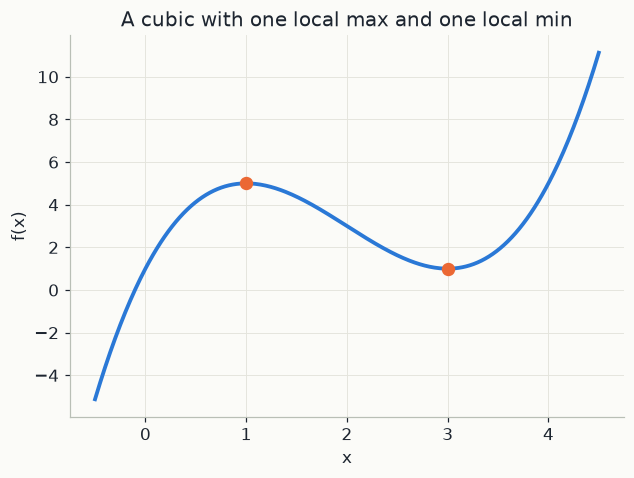

In [5]:
f_num = sp.lambdify(x, f, "numpy")
xs = np.linspace(-0.5, 4.5, 400)
fig, ax = plt.subplots(figsize=(6.5, 4.5))
ax.plot(xs, f_num(xs), color=mlutils.BLUE, lw=2.5)
for c in critical_points:
    cv = float(c)
    ax.scatter([cv], [f_num(cv)], color=mlutils.ORANGE, zorder=5, s=60)
ax.set(xlabel="x", ylabel="f(x)", title="A cubic with one local max and one local min")

## 6. The same idea trains a model

Section 3 described training as minimising a **loss function** — usually a
high-dimensional version of the picture above. Take the simplest case: fitting a single slope $w$ through the origin to minimise
the mean squared error

$$L(w) = \frac{1}{n}\sum_i (y_i - w x_i)^2$$

This is a parabola in $w$ (one variable, easy to visualise), and its minimum has a
closed form — set $L'(w) = 0$ and solve.

In [6]:
rng = np.random.default_rng(0)
n = 50
x_data = rng.uniform(0, 10, n)
y_data = 2.3 * x_data + rng.normal(0, 2, n)

w = sp.symbols("w")
L = sum((y_data[i] - w * x_data[i])**2 for i in range(n)) / n
L_prime = sp.diff(L, w)
w_star = sp.solve(sp.Eq(L_prime, 0), w)[0]
print(f"closed-form minimiser: w* = {float(w_star):.4f}")

closed-form minimiser: w* = 2.3342


gradient descent after 200 steps: w = 2.3342  (target 2.3342)


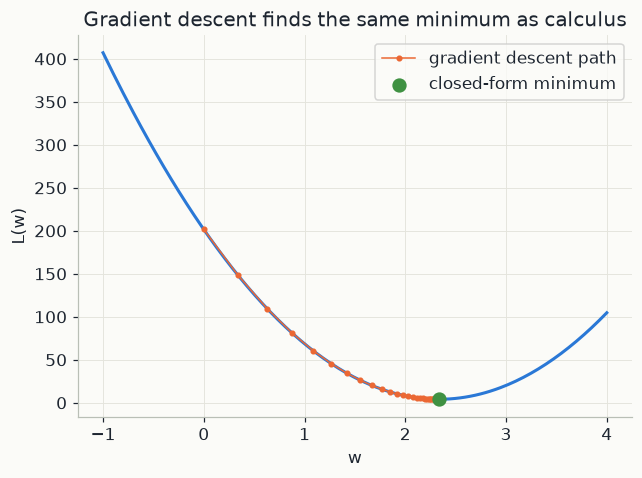

In [7]:
# gradient descent: repeatedly step "downhill" instead of solving analytically
L_prime_num = sp.lambdify(w, L_prime, "numpy")
w_gd, lr = 0.0, 0.002
path = [w_gd]
for _ in range(200):
    w_gd = w_gd - lr * L_prime_num(w_gd)
    path.append(w_gd)
print(f"gradient descent after 200 steps: w = {w_gd:.4f}  (target {float(w_star):.4f})")

L_num = sp.lambdify(w, L, "numpy")
ws = np.linspace(-1, 4, 200)
fig, ax = plt.subplots(figsize=(6.5, 4.5))
ax.plot(ws, L_num(ws), color=mlutils.BLUE, lw=2)
ax.plot(path, [L_num(p) for p in path], color=mlutils.ORANGE, marker="o", ms=3, lw=1,
        label="gradient descent path")
ax.scatter([float(w_star)], [L_num(float(w_star))], color=mlutils.GREEN, zorder=5, s=70,
           label="closed-form minimum")
ax.set(xlabel="w", ylabel="L(w)", title="Gradient descent finds the same minimum as calculus")
ax.legend()

Both routes land in the same place: solving $L'(w)=0$ directly, or taking small steps
opposite the gradient until it flattens out. Closed-form solutions exist for linear
regression; almost nothing else in this course has one, which is why gradient descent
(chapter 06) and backpropagation (chapter 07 onward) matter.

## Exercises

### Exercise 1: A function with two local minima
Let $g(x) = x^4 - 4x^2$. Find all critical points and classify each with the
second-derivative test. (Hint: the second-derivative test is inconclusive at a
saddle/inflection point, i.e. when $f''=0$ too — check whether that happens here.)

<details><summary>Solution</summary>

```python
g = x**4 - 4*x**2
g_prime = sp.diff(g, x)
g_double = sp.diff(g_prime, x)
pts = sp.solve(sp.Eq(g_prime, 0), x)
for c in pts:
    print(c, g_double.subs(x, c))
# x = -sqrt(2), sqrt(2): f''>0 -> local minima; x = 0: f''<0 -> local maximum
```
</details>

### Exercise 2: Learning rate too large
Rerun the gradient descent cell with `lr = 0.02` (10x larger), then with `lr = 0.03`.
Before running, predict what happens from the contraction factor $1 - 2a\eta$ of
Section 3, with $a$ = `np.mean(x_data**2)`. Relate the result to what "diverging
loss" looks like during neural-network training in later chapters.

<details><summary>Solution</summary>

Here $a \approx 36.3$, so the threshold is $\eta = 1/a \approx 0.028$. With `lr = 0.02`
the factor is about $-0.45$: the path jumps from one side of the minimum to the other
but still converges. With `lr = 0.03` the factor is about $-1.18$: each step
overshoots further than the last and the loss increases every iteration instead of
decreasing — the numerical analogue of an unstable difference equation. This is exactly what an exploding training loss means
in chapters 06-09.
</details>

## Key takeaways

- A function's local extrema occur where its derivative is zero; the sign of the
  second derivative there tells a maximum from a minimum.
- Training a model is minimising a loss function over its parameters — the same
  calculus, just in (often thousands of) more dimensions.
- Gradient descent — repeatedly stepping opposite the gradient — finds the same
  minimum as solving $L'=0$ directly, without ever writing down a closed form. That's
  the only option once a closed form doesn't exist.